In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Load Brent oil price data
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Quick overview
df.head()


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
# Check basic info and missing values
df.info()

# Basic statistics
print("Raw Price Statistics:\n", df['Price'].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB
Raw Price Statistics:
 count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64


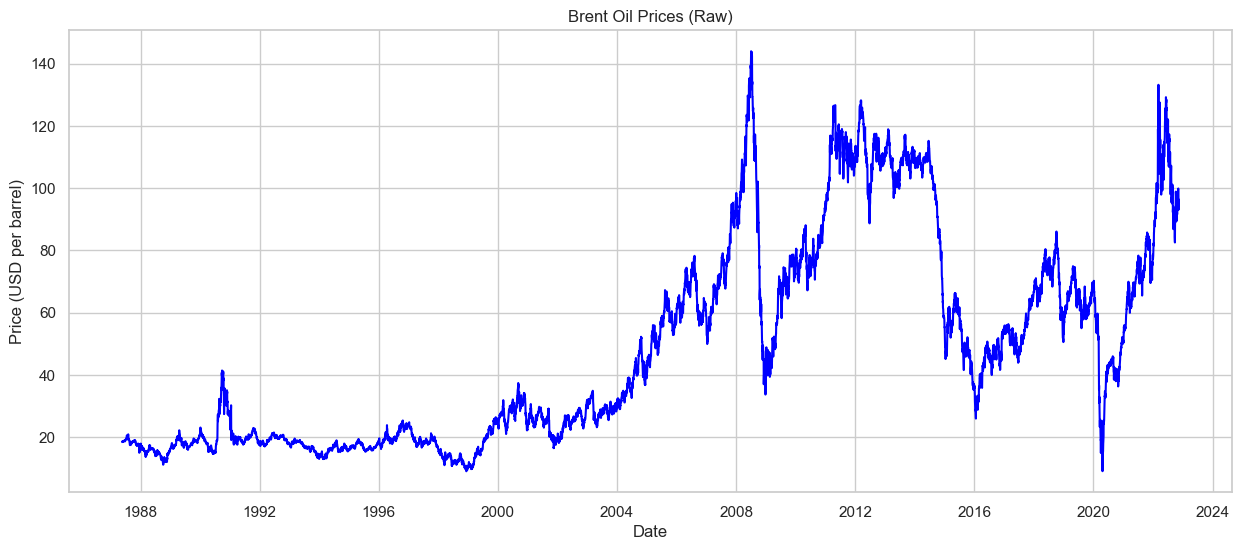

In [6]:
plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Price'], color='blue')
plt.title("Brent Oil Prices (Raw)")
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(True)
plt.show()


In [7]:
# Compute daily log returns
df['Log_Return'] = np.log(df['Price']).diff()

# Drop first NaN value
df_returns = df.dropna().reset_index(drop=True)

df_returns.head()


,Date,Price,Log_Return
0,1987-05-21,18.45,-0.009709
1,1987-05-22,18.55,0.005405
2,1987-05-25,18.60,0.002692
3,1987-05-26,18.63,0.001612
4,1987-05-27,18.60,-0.001612


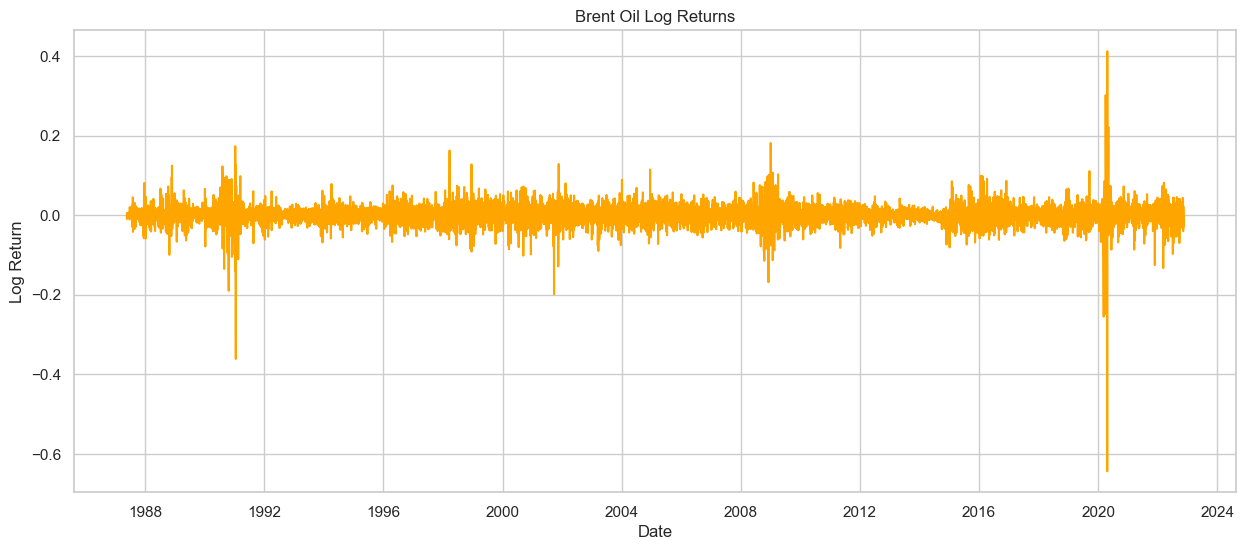

In [8]:
plt.figure(figsize=(15,6))
plt.plot(df_returns['Date'], df_returns['Log_Return'], color='orange')
plt.title("Brent Oil Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()


In [9]:
print("Log Return Statistics:\n", df_returns['Log_Return'].describe())


Log Return Statistics:
 count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Return, dtype: float64


In [ ]:
# Observations for interim report
print("""
Observations from initial EDA:
- The raw price series shows clear long-term trends and major spikes during events like the 2008 financial crisis and 2020 COVID-19 pandemic.
- Log returns highlight volatility clustering, periods of calm and high turbulence.
- Mean and standard deviation of log returns provide a sense of typical daily price changes.
- This preliminary analysis sets the stage for Bayesian change point modeling in Task 2.
""")
